In [1]:
# non-processed data - no feature extraction
import pandas as pd
from sklearn.model_selection import train_test_split

file_path = '/kaggle/input/hc3-project-cleaned-essays/filtered_essay_corpus.csv'
df = pd.read_csv(file_path)

zero_shot_adv_df = pd.read_csv("/kaggle/input/genai-project-adversarial-essays/adversarial_scratch_set_cleaned.csv")
few_shot_adv_df = pd.read_csv("/kaggle/input/genai-project-adversarial-essays/few_shot_adversarial_scratch_set.csv")

train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['generated']
)

human_train_df = train_df[train_df['generated'] == 0]

print(f"Original Dataset: {len(df)} rows")
print(f"---")
print(f"Training Set (Mixed) for Members 1 & 2: {len(train_df)} rows")
print(f"Test Set (Mixed) for All Members:       {len(test_df)} rows")
print(f"Human-Only Training Set for Member 3:   {len(human_train_df)} rows")

train_df.to_csv("train_set_mixed.csv", index=False)
test_df.to_csv("test_set_mixed.csv", index=False)
human_train_df.to_csv("train_set_human_only.csv", index=False)

print("\nFiles saved successfully: 'train_set_mixed.csv', 'test_set_mixed.csv', 'train_set_human_only.csv'")

Original Dataset: 290888 rows
---
Training Set (Mixed) for Members 1 & 2: 232710 rows
Test Set (Mixed) for All Members:       58178 rows
Human-Only Training Set for Member 3:   91190 rows

Files saved successfully: 'train_set_mixed.csv', 'test_set_mixed.csv', 'train_set_human_only.csv'


In [2]:
# embeddings
import numpy as np
from sentence_transformers import SentenceTransformer

print("Loading Sentence Transformer...")
embedder = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Encoding {len(human_train_df)} Training Samples...")
X_train = embedder.encode(human_train_df['text'].tolist(), show_progress_bar=True)

print(f"Encoding {len(test_df)} Test Samples...")
X_test = embedder.encode(test_df['text'].tolist(), show_progress_bar=True)

print(f"\nEncoding {len(zero_shot_adv_df)} Zero-Shot Adversarial Samples...")
X_zs_adv = embedder.encode(zero_shot_adv_df['text'].tolist(), show_progress_bar=True)

print(f"\nEncoding {len(few_shot_adv_df)} Few-Shot Adversarial Samples...")
X_fs_adv = embedder.encode(few_shot_adv_df['text'].tolist(), show_progress_bar=True)

np.save('X_train_human_embeddings.npy', X_train)
print("Saved 'X_train_human_embeddings.npy'")

np.save('X_test_mixed_embeddings.npy', X_test)
print("Saved 'X_test_mixed_embeddings.npy'")

np.save('X_zs_adv_embeddings.npy', X_zs_adv)
print("Saved 'X_zs_+adv_embeddings.npy'")

np.save('X_fs_adv_embeddings.npy', X_fs_adv)
print("Saved 'X_fs_+adv_embeddings.npy'")

2025-12-06 15:11:13.788936: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765033874.211169      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765033874.327016      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...


Encoding 500 Zero-Shot Adversarial Samples...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]


Encoding 500 Few-Shot Adversarial Samples...


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Saved 'X_train_human_embeddings.npy'
Saved 'X_test_mixed_embeddings.npy'
Saved 'X_zs_+adv_embeddings.npy'
Saved 'X_fs_+adv_embeddings.npy'


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib

file_path = '/kaggle/input/features-matrix/features_matrix.csv' 
df = pd.read_csv(file_path)

zero_shot_adv_df = pd.read_csv("/kaggle/input/adv-features/adversarial_feature_matrix.csv")
few_shot_adv_df = pd.read_csv("/kaggle/input/adv-features/few_shot_adversarial_feature_matrix.csv")

exclude_cols = ['generated', 'original_text_idx']
feature_cols = [c for c in df.columns if c not in exclude_cols and pd.api.types.is_numeric_dtype(df[c])]

print(f"Features to Normalize ({len(feature_cols)}): {feature_cols}")

train_df, test_df = train_test_split(
    df, 
    test_size=0.2, 
    random_state=42, 
    stratify=df['generated']
)

scaler = StandardScaler()
scaler.fit(train_df[feature_cols])

train_df[feature_cols] = scaler.transform(train_df[feature_cols])
test_df[feature_cols] = scaler.transform(test_df[feature_cols])
zero_shot_adv_df[feature_cols] = scaler.transform(zero_shot_adv_df[feature_cols])
few_shot_adv_df[feature_cols] = scaler.transform(few_shot_adv_df[feature_cols])

human_train_df = train_df[train_df['generated'] == 0]

train_df.to_csv("train_set_mixed_normalized.csv", index=False)
test_df.to_csv("test_set_mixed_normalized.csv", index=False)
human_train_df.to_csv("train_set_human_only_normalized.csv", index=False)

print(f"\n--- Processing Complete ---")
print(f"Training Set: {len(train_df)} rows (Normalized)")
print(f"Test Set:     {len(test_df)} rows (Normalized)")
print(f"Human Only:   {len(human_train_df)} rows (Normalized)")

Features to Normalize (6): ['perplexity', 'burstiness', 'flesch_score', 'grade_level', 'word_count', 'naturalness_score']

--- Processing Complete ---
Training Set: 232710 rows (Normalized)
Test Set:     58178 rows (Normalized)
Human Only:   91190 rows (Normalized)


In [6]:
import numpy as np

X_train = train_df[feature_cols].values
y_train = train_df['generated'].values

X_test = test_df[feature_cols].values
y_test = test_df['generated'].values

X_zs_adv = zero_shot_adv_df[feature_cols].values
X_fs_adv = few_shot_adv_df[feature_cols].values
y_adv = np.ones(len(zero_shot_adv_df))

human_train_df = train_df[train_df['generated'] == 0]
X_train_human = human_train_df[feature_cols].values

np.save('X_train_human_features.npy', X_train_human)
print("Saved 'X_train_human_features.npy'")

np.save('X_test_mixed_features.npy', X_test)
print("Saved 'X_test_mixed_features.npy'")

np.save('y_test_features.npy', y_test)
print("Saved 'y_test_features.npy'")

np.save('X_zs_adv_features.npy', X_zs_adv)
print("Saved 'X_zs_adv_features.npy'")

np.save('X_fs_adv_features.npy', X_fs_adv)
print("Saved 'X_fs_adv_features.npy'")

Saved 'X_train_human_features.npy'
Saved 'X_test_mixed_features.npy'
Saved 'y_test_features.npy'
Saved 'X_zs_adv_features.npy'
Saved 'X_fs_adv_features.npy'


In [7]:
import numpy as np
import pandas as pd
from sklearn.svm import OneClassSVM
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, f1_score, accuracy_score, recall_score
from sklearn.metrics import roc_auc_score

def get_auroc(model, X_test, y_test, model_type="sklearn"):
    try:
        scores = model.decision_function(X_test)
    except:
        scores = model.decision_function(X_test)
        
    ai_probability_scores = -scores 
    
    try:
        auroc = roc_auc_score(y_test, ai_probability_scores)
        return auroc
    except ValueError:
        return 0.0 

def evaluate_model(model, X_test, y_test, model_name, dataset_name):
    print(f"[{model_name}] Predicting on {dataset_name}...")
    
    preds_raw = model.predict(X_test)
    
    preds_mapped = [0 if x == 1 else 1 for x in preds_raw]
    
    acc = accuracy_score(y_test, preds_mapped)
    f1 = f1_score(y_test, preds_mapped, pos_label=1, zero_division=0)
    
    ai_indices = [i for i, x in enumerate(y_test) if x == 1]
    if len(ai_indices) > 0:
        ai_preds = [preds_mapped[i] for i in ai_indices]
        ai_recall = np.mean(ai_preds)
    else:
        ai_recall = 0.0
        
    return {
        "Model": model_name,
        "Dataset": dataset_name,
        "Accuracy": acc,
        "F1_Score (AI Class)": f1,
        "AI_Recall": ai_recall,
        "AUROC": get_auroc(model, X_test, y_test)
    }

results_log = []

In [21]:
print("\n" + "="*40)
print("  EXPERIMENT A: OCSVM on SEMANTIC EMBEDDINGS")
print("="*40)

try:
    X_train_emb = np.load('X_train_human_embeddings.npy') # Human Only (The "Target" class) 
    X_test_emb = np.load('X_test_mixed_embeddings.npy')   # Mixed Human/AI
    y_test = np.load('y_test_features.npy')               # Labels
    
    X_zs_adv_emb = np.load('X_zs_adv_embeddings.npy')
    X_fs_adv_emb = np.load('X_fs_adv_embeddings.npy')
    y_adv = np.ones(len(X_zs_adv_emb)) 

    print("Training OCSVM (RBF Kernel)...")
    oc_svm = OneClassSVM(kernel='rbf', gamma='scale', nu=0.05)
    oc_svm.fit(X_train_emb)
    
    # Evaluate
    results_log.append(evaluate_model(oc_svm, X_test_emb, y_test, "OCSVM (Embeddings)", "Standard Test"))
    results_log.append(evaluate_model(oc_svm, X_zs_adv_emb, y_adv, "OCSVM (Embeddings)", "Zero-Shot Adversarial Test"))
    results_log.append(evaluate_model(oc_svm, X_fs_adv_emb, y_adv, "OCSVM (Embeddings)", "Few-Shot Adversarial Test"))

except Exception as e:
    print(f"Skipping Experiment A: {e}")


  EXPERIMENT A: OCSVM on SEMANTIC EMBEDDINGS
Training OCSVM (RBF Kernel)...
[OCSVM (Embeddings)] Predicting on Standard Test...
[OCSVM (Embeddings)] Predicting on Zero-Shot Adversarial Test...
[OCSVM (Embeddings)] Predicting on Few-Shot Adversarial Test...


In [22]:
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

print("\n" + "="*40)
print("  EXPERIMENT B: iForest on STYLISTIC FEATURES")
print("="*40)

try:
    X_train_feat = np.load('X_train_human_features.npy') # Human Only Training Data
    X_test_feat = np.load('X_test_mixed_features.npy')         # Standard Mixed Test Data
    X_zs_adv_feat = np.load('X_zs_adv_features.npy')           # Adversarial Test Data
    X_fs_adv_feat = np.load('X_fs_adv_features.npy')           # Adversarial Test Data
    
    print("Imputing NaNs...")
    imputer = SimpleImputer(strategy='mean')
    
    X_train_feat = imputer.fit_transform(X_train_feat)
    X_test_feat = imputer.transform(X_test_feat)
    X_zs_adv_feat = imputer.transform(X_zs_adv_feat)
    X_fs_adv_feat = imputer.transform(X_fs_adv_feat)

    print("Normalizing features (StandardScaler)...")
    scaler = StandardScaler()
    
    X_train_feat = scaler.fit_transform(X_train_feat)
    X_test_feat = scaler.transform(X_test_feat)    
    X_zs_adv_feat = imputer.transform(X_zs_adv_feat)
    X_fs_adv_feat = imputer.transform(X_fs_adv_feat)

    print("Training Isolation Forest...")
    iso_forest = IsolationForest(contamination='auto', random_state=42) 
    iso_forest.fit(X_train_feat)
    
    results_log.append(evaluate_model(iso_forest, X_test_feat, y_test, "iForest (Features)", "Standard Test"))
    results_log.append(evaluate_model(iso_forest, X_zs_adv_feat, y_adv, "iForest (Features)", "Zero-Shot Adversarial Test"))
    results_log.append(evaluate_model(iso_forest, X_fs_adv_feat, y_adv, "iForest (Features)", "Few-Shot Adversarial Test"))

except Exception as e:
    print(f"Skipping Experiment B due to error: {e}")


  EXPERIMENT B: iForest on STYLISTIC FEATURES
Imputing NaNs...
Normalizing features (StandardScaler)...
Training Isolation Forest...
[iForest (Features)] Predicting on Standard Test...
[iForest (Features)] Predicting on Zero-Shot Adversarial Test...
[iForest (Features)] Predicting on Few-Shot Adversarial Test...


In [25]:
print("\n" + "="*40)
print("  COMPARATIVE RESULTS")
print("="*40)

results_df = pd.DataFrame(results_log)

if not results_df.empty:
    print("\n--- Performance on Standard Data ---")
    standard_res = results_df[results_df['Dataset'] == 'Standard Test']
    print(standard_res[['Model', 'Accuracy', 'F1_Score (AI Class)', 'AI_Recall', 'AUROC']].to_string(index=False))
    
    print("\n--- Performance on Zero-Shot Adversarial Data ---")
    zs_adv_res = results_df[results_df['Dataset'] == 'Zero-Shot Adversarial Test']
    print(zs_adv_res[['Model', 'Accuracy', 'F1_Score (AI Class)', 'AI_Recall', 'AUROC']].to_string(index=False))

    print("\n--- Performance on Few-Shot Adversarial Data ---")
    fs_adv_res = results_df[results_df['Dataset'] == 'Few-Shot Adversarial Test']
    print(fs_adv_res[['Model', 'Accuracy', 'F1_Score (AI Class)', 'AI_Recall', 'AUROC']].to_string(index=False))
else:
    print("No results generated.")


  COMPARATIVE RESULTS

--- Performance on Standard Data ---
             Model  Accuracy  F1_Score (AI Class)  AI_Recall    AUROC
iForest (Features)  0.388102             0.072967   0.039599 0.607338
OCSVM (Embeddings)  0.431297             0.174830   0.099067 0.604362
iForest (Features)  0.388102             0.072967   0.039599 0.607338

--- Performance on Zero-Shot Adversarial Data ---
             Model  Accuracy  F1_Score (AI Class)  AI_Recall  AUROC
iForest (Features)     0.832             0.908297      0.832    0.0
OCSVM (Embeddings)     0.012             0.023715      0.012    0.0
iForest (Features)     0.832             0.908297      0.832    0.0

--- Performance on Few-Shot Adversarial Data ---
             Model  Accuracy  F1_Score (AI Class)  AI_Recall  AUROC
iForest (Features)     0.564             0.721228      0.564    0.0
OCSVM (Embeddings)     0.028             0.054475      0.028    0.0
iForest (Features)     0.564             0.721228      0.564    0.0


=== FEATURE DISTRIBUTION STATISTICS (Normalized) ===
     Feature  Human (Mean)  Standard AI (Mean)  Zero-Shot Adv (Mean)  Few-Shot Adv (Mean)
  Perplexity        0.0000             -1.1400                2.3983               1.5037
  Burstiness        0.0000              0.0763               -0.3405              -0.3935
Flesch Score       -0.0000              0.1145               -1.8064              -1.4075
 Grade Level        0.0000              0.0407                0.8880               0.6005
  Word Count       -0.0000             -0.2277               -0.6526              -0.6087
 Naturalness        0.0000             -0.7214                0.4148              -0.0173


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

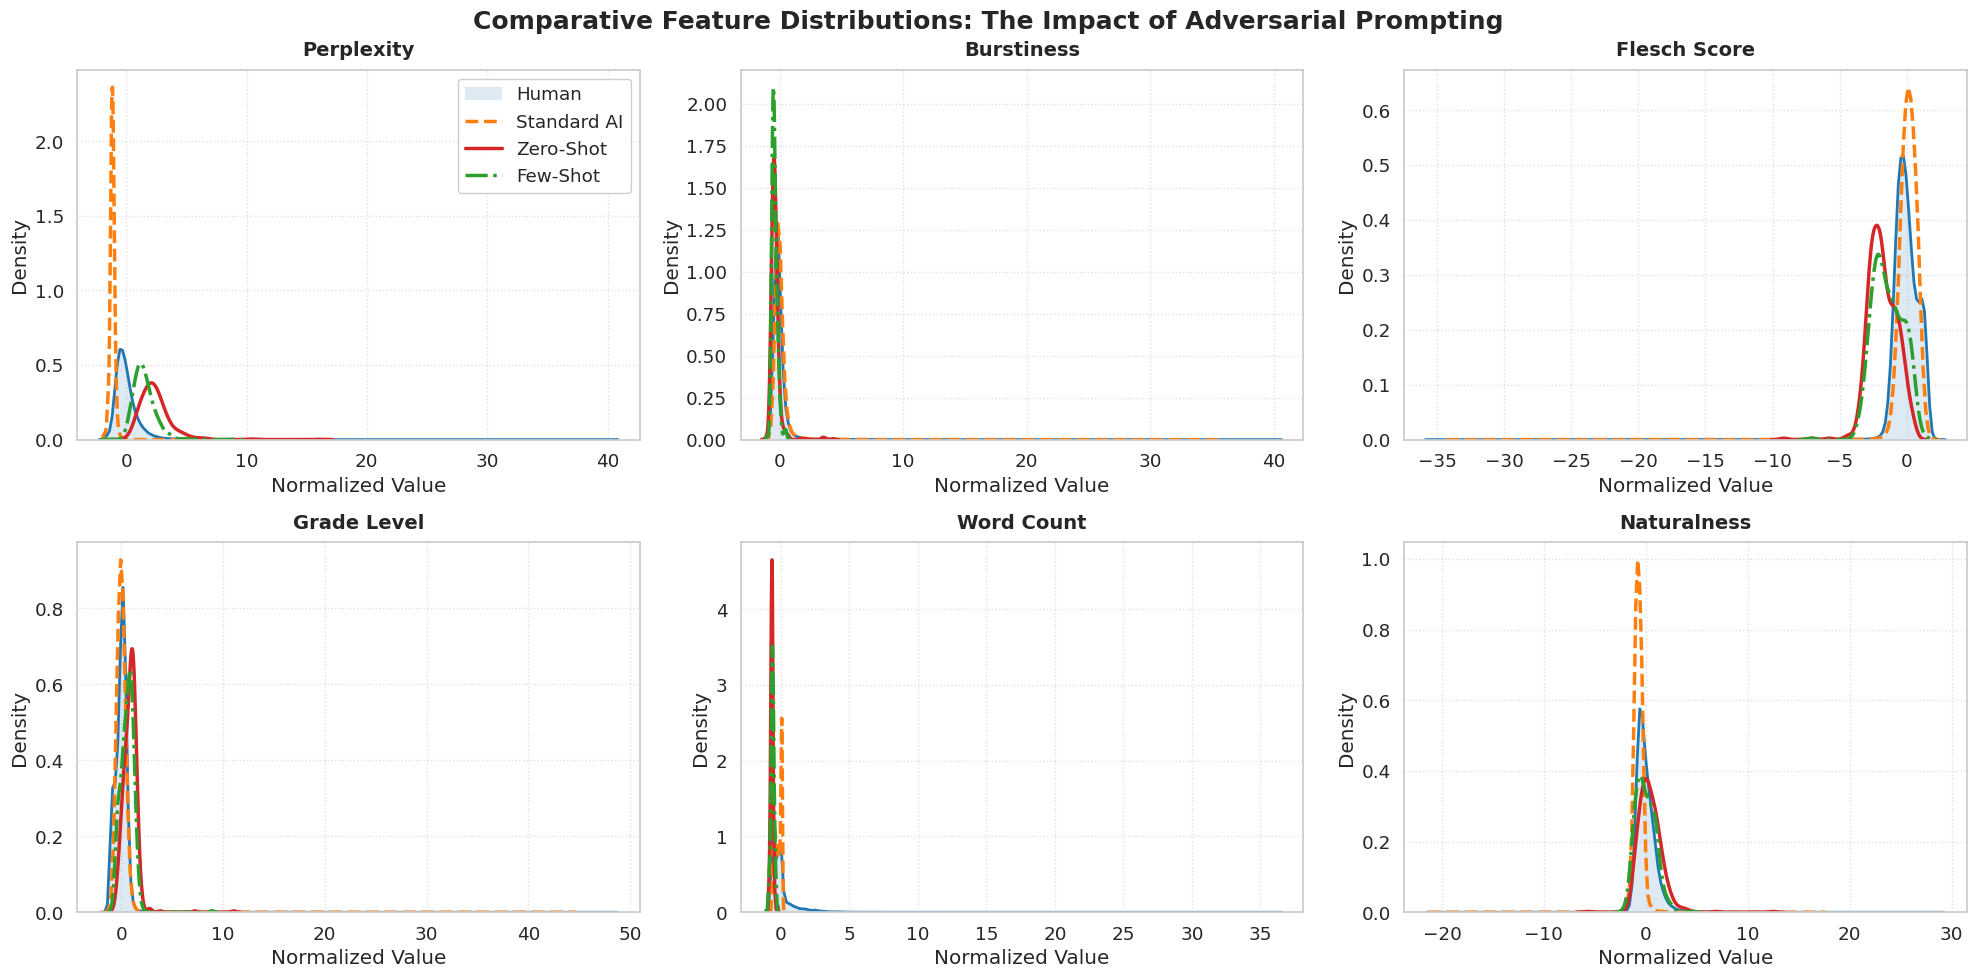

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

y_test = np.load('y_test_features.npy')    

n_features = X_train_feat.shape[1]
feature_cols = ['Perplexity', 'Burstiness', 'Flesch Score', 'Grade Level', 'Word Count', 'Naturalness'] 

# Filter Standard AI from mixed test set
std_ai_data = X_test_feat[y_test==1]

# Calculate Means (Averages) for each group
stats_data = {
    'Feature': feature_cols,
    'Human (Mean)': np.mean(X_train_feat, axis=0),
    'Standard AI (Mean)': np.mean(std_ai_data, axis=0),
    'Zero-Shot Adv (Mean)': np.mean(X_zs_adv_feat, axis=0),
    'Few-Shot Adv (Mean)': np.mean(X_fs_adv_feat, axis=0)
}

df_stats = pd.DataFrame(stats_data)
print("=== FEATURE DISTRIBUTION STATISTICS (Normalized) ===")
print(df_stats.to_string(index=False, float_format="%.4f"))
print("="*60)


sns.set_theme(style="whitegrid", context="notebook", font_scale=1.2)
colors = {
    'Human': '#1f77b4',      # Muted Blue
    'Std AI': '#ff7f0e',     # Safety Orange
    'ZS Adv': '#d62728',     # Brick Red
    'FS Adv': '#2ca02c'      # Cooked Asparagus Green
}

n_features = X_train_feat.shape[1]
n_cols = 3
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
axes = axes.flatten()

for i in range(n_features):
    ax = axes[i]
    
    try:
        f_name = feature_cols[i]
    except:
        f_name = f"Feature {i}"

    # --- DYNAMIC SCALING ---
    # Combine data to find the full range for this feature
    all_data = np.concatenate([
        X_train_feat[:, i],
        std_ai_data[:, i],
        X_zs_adv_feat[:, i],
        X_fs_adv_feat[:, i]
    ])
    
    d_min, d_max = np.min(all_data), np.max(all_data)
    padding = (d_max - d_min) * 0.05
    ax.set_xlim(d_min - padding, d_max + padding)
    # -----------------------

    # 1. Human (Baseline)
    sns.kdeplot(X_train_feat[:, i], ax=ax, 
                fill=True, color=colors['Human'], alpha=0.15, linewidth=0,
                label='Human')
    sns.kdeplot(X_train_feat[:, i], ax=ax, 
                color=colors['Human'], linewidth=2)

    # 2. Standard AI
    sns.kdeplot(std_ai_data[:, i], ax=ax, 
                color=colors['Std AI'], linewidth=2.5, linestyle="--",
                label='Standard AI')

    # 3. Zero-Shot Adversarial
    sns.kdeplot(X_zs_adv_feat[:, i], ax=ax, 
                color=colors['ZS Adv'], linewidth=2.5,
                label='Zero-Shot')

    # 4. Few-Shot Adversarial
    sns.kdeplot(X_fs_adv_feat[:, i], ax=ax, 
                color=colors['FS Adv'], linewidth=2.5, linestyle="-.",
                label='Few-Shot')

    # Aesthetics
    ax.set_title(f"{f_name}", fontsize=14, fontweight='bold', pad=10)
    ax.set_xlabel("Normalized Value")
    ax.set_ylabel("Density")
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if i == 0:
        ax.legend(loc='upper right', frameon=True, framealpha=0.95, fancybox=True)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.suptitle("Comparative Feature Distributions: The Impact of Adversarial Prompting", fontsize=18, fontweight='bold')
plt.show()